In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [20]:

debt_complaints_2021 = pd.read_csv("debt-complaints-2021.csv")
debt_complaints_2022 = pd.read_csv("debt-complaints-2022.csv")
debt_complaints_2023 = pd.read_csv("debt-complaints-2023.csv")
debt_complaints_2024 = pd.read_csv("debt-complaints-2024.csv")
debt_complaints_2025 = pd.read_csv("2025_complaints_combined.csv")

In [21]:
import os

print(os.listdir("/content"))

['.config', '2025_complaints_combined.csv', 'debt-complaints-2024.csv', '.ipynb_checkpoints', 'debt-complaints-2021.csv', 'debt-complaints-2023.csv', 'debt-complaints-2022.csv', 'sample_data']


In [22]:
for year in range(2021, 2026):
    df_year = globals()[f"debt_complaints_{year}"]

    df_year["Relief"] = df_year["Company response to consumer"].map({
        "Closed with monetary relief": 1,
        "Closed with non-monetary relief": 1,
        "Closed with explanation": 0
    })

In [23]:
debt_complaints_2023["Relief"].value_counts()

,count
Relief,
0.0,41944
1.0,7690


In [24]:
print(debt_complaints_2021.shape)
print(debt_complaints_2022.shape)
print(debt_complaints_2023.shape)
print(debt_complaints_2024.shape)
print(debt_complaints_2025.shape)

(4651, 16)
(45230, 16)
(49844, 16)
(68206, 16)
(128799, 16)


In [25]:
debt_complaints_2021["Relief"] = debt_complaints_2021["Company response to consumer"].map({
    "Closed with monetary relief": 1,
    "Closed with non-monetary relief": 1,
    "Closed with explanation": 0
})

debt_complaints_2022["Relief"] = debt_complaints_2022["Company response to consumer"].map({
    "Closed with monetary relief": 1,
    "Closed with non-monetary relief": 1,
    "Closed with explanation": 0
})

debt_complaints_2023["Relief"] = debt_complaints_2023["Company response to consumer"].map({
    "Closed with monetary relief": 1,
    "Closed with non-monetary relief": 1,
    "Closed with explanation": 0
})

debt_complaints_2024["Relief"] = debt_complaints_2024["Company response to consumer"].map({
    "Closed with monetary relief": 1,
    "Closed with non-monetary relief": 1,
    "Closed with explanation": 0
})

debt_complaints_2025["Relief"] = debt_complaints_2025["Company response to consumer"].map({
    "Closed with monetary relief": 1,
    "Closed with non-monetary relief": 1,
    "Closed with explanation": 0
})

In [26]:
print("2021")
print(debt_complaints_2021["Relief"].value_counts(dropna=False))

print("\n2022")
print(debt_complaints_2022["Relief"].value_counts(dropna=False))

print("\n2023")
print(debt_complaints_2023["Relief"].value_counts(dropna=False))

print("\n2024")
print(debt_complaints_2024["Relief"].value_counts(dropna=False))

print("\n2025")
print(debt_complaints_2025["Relief"].value_counts(dropna=False))

2021
Relief
0.0    4159
1.0     479
NaN      13
Name: count, dtype: int64

2022
Relief
0.0    39114
1.0     5951
NaN      165
Name: count, dtype: int64

2023
Relief
0.0    41944
1.0     7690
NaN      210
Name: count, dtype: int64

2024
Relief
0.0    48774
1.0    19092
NaN      340
Name: count, dtype: int64

2025
Relief
0.0    94756
1.0    33042
NaN     1001
Name: count, dtype: int64


In [27]:
all_complaints = pd.concat([
    debt_complaints_2021,
    debt_complaints_2022,
    debt_complaints_2023,
    debt_complaints_2024,
    debt_complaints_2025
], ignore_index=True)

In [28]:
all_complaints.shape

(296730, 16)

In [29]:
company_summary = all_complaints.groupby("Company").agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

In [30]:
company_summary["relief_rate"] = company_summary["relief_rate"] * 100

In [31]:
company_summary.head(20)

,Company,eligible_complaints,relief_cases,relief_rate
0,"1 Auto Finance, Inc.",0,0.0,NaN
1,"1803 Capital, LLC",6,0.0,0.0
2,1ST PREFERENCE MORTGAGE CORP,1,0.0,0.0
3,"1ST RESULTS BILLINGS & COLLECTIONS, INC.",5,3.0,60.0
4,"1st Capital Finance of South Carolina, Inc.",1,0.0,0.0
5,1st Franklin Financial Corporation,41,0.0,0.0
6,21ST MORTGAGE CORP.,12,0.0,0.0
7,2233 Paradise Road LLC,0,0.0,NaN
8,2288984 Ontario Inc.,43,0.0,0.0
9,"391 Financial, Inc.",1,0.0,0.0


In [32]:
company_summary.sort_values("relief_rate", ascending = False).head(20)

,Company,eligible_complaints,relief_cases,relief_rate
160,"Adam I. Skolnik, P.A. d/b/a Law Office of Adam...",1,1.0,100.0
3051,"Triton Management Group, Inc",1,1.0,100.0
1739,"Lakeview Law Group, PLLC",4,4.0,100.0
1424,Greg King DBA Karma Consulting,1,1.0,100.0
1335,GOLD STAR MORTGAGE FINANCIAL,1,1.0,100.0
2214,"OM Financial, LLC",1,1.0,100.0
1977,"Merchants Financial Guardian, Inc.",1,1.0,100.0
421,Bailey & Galyen,1,1.0,100.0
2972,The Judgment Group,1,1.0,100.0
1413,Great Lakes Entities,1,1.0,100.0


In [36]:
company_summary_100 = company_summary[
    company_summary["total_complaints"] >= 100
]
company_summary_100.sort_values(
    "relief_rate", ascending=False
).head(20)

KeyError: 'total_complaints'

In [37]:
company_summary_100.sort_values(
    "relief_rate", ascending=True
).head(20)

NameError: name 'company_summary_100' is not defined

In [ ]:
company_summary = all_complaints.groupby("Company").agg(
    total_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean"),
    timely_rate=("Timely response?", lambda x: (x == "Yes").mean())
).reset_index()


company_summary["relief_rate"] = company_summary["relief_rate"] * 100
company_summary["timely_rate"] = company_summary["timely_rate"] * 100


company_summary.head(20)

In [ ]:
for year, data in [
    (2021, debt_complaints_2021),
    (2022, debt_complaints_2022),
    (2023, debt_complaints_2023),
    (2024, debt_complaints_2024),
    (2025, debt_complaints_2025)
]:
    print(f"\n{year}")
    print(data["Company response to consumer"].value_counts(dropna=False))

In [ ]:
for data in [
    debt_complaints_2021,
    debt_complaints_2022,
    debt_complaints_2023,
    debt_complaints_2024,
    debt_complaints_2025
]:
    data["Relief"] = data["Company response to consumer"].map({
        "Closed with monetary relief": 1,
        "Closed with non-monetary relief": 1,
        "Closed with explanation": 0
    })

In [34]:
debt_complaints_2021["Year"] = 2021
debt_complaints_2022["Year"] = 2022
debt_complaints_2023["Year"] = 2023
debt_complaints_2024["Year"] = 2024
debt_complaints_2025["Year"] = 2025

In [ ]:
all_complaints = pd.concat([
    debt_complaints_2021,
    debt_complaints_2022,
    debt_complaints_2023,
    debt_complaints_2024,
    debt_complaints_2025
], ignore_index=True)

In [ ]:
print(debt_complaints_2021["Relief"].value_counts(dropna=False))
print(debt_complaints_2022["Relief"].value_counts(dropna=False))
print(debt_complaints_2023["Relief"].value_counts(dropna=False))
print(debt_complaints_2024["Relief"].value_counts(dropna=False))
print(debt_complaints_2025["Relief"].value_counts(dropna=False))

In [ ]:
print(all_complaints["Year"].value_counts().sort_index())

In [ ]:
print(all_complaints.columns.tolist())

In [ ]:
print(all_complaints.columns[all_complaints.columns.str.contains("Relief", case=False)])

In [ ]:
print(all_complaints[["Year", "Company", "Relief"]].head())

In [ ]:
company_year = all_complaints.groupby(["Year", "Company"]).agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

company_year["relief_rate"] = company_year["relief_rate"] * 100

In [ ]:
company_year.head(20)

In [ ]:
company_year_filtered = company_year[
    company_year["eligible_complaints"] >= 100
].copy()

In [ ]:
company_year_filtered.head(20)

In [ ]:
company_year_filtered.head(20)

In [ ]:
company_state_year = all_complaints.groupby(
    ["Year", "Company", "State"]
).agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

company_state_year["relief_rate"] *= 100

In [ ]:
company_totals = all_complaints.groupby("Company")["Relief"].count().sort_values(ascending=False)

company_totals.head(20)

In [ ]:
company_name = "PUT COMPANY NAME HERE"

company_plot = company_state_year[
    (company_state_year["Company"] == company_name) &
    (company_state_year["eligible_complaints"] >= 50)
]

heatmap_data = company_plot.pivot(
    index="State",
    columns="Year",
    values="relief_rate"
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 14))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title(f"Relief Rate by State and Year — {company_name}")
plt.xlabel("Year")
plt.ylabel("State")
plt.show()

In [ ]:
# Keep companies with at least 100 eligible complaints in EVERY year
companies_with_enough_data = (
    company_year
    .groupby("Company")["eligible_complaints"]
    .min()
)

companies_to_plot = companies_with_enough_data[
    companies_with_enough_data >= 100
].index

company_trends = company_year[
    company_year["Company"].isin(companies_to_plot)
].copy()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for company in company_trends["Company"].unique():
    company_data = company_trends[
        company_trends["Company"] == company
    ].sort_values("Year")

    plt.plot(
        company_data["Year"],
        company_data["relief_rate"],
        marker="o",
        label=company
    )

plt.xlabel("Year")
plt.ylabel("Relief Rate (%)")
plt.title("Relief Rate by Company, 2021–2025")
plt.xticks([2021, 2022, 2023, 2024, 2025])
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
year_relief = all_complaints.groupby("Year").agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

year_relief["relief_rate"] *= 100

plt.figure(figsize=(10, 6))

plt.plot(
    year_relief["Year"],
    year_relief["relief_rate"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Relief Rate (%)")
plt.title("Relief Rate of Debt Collection Complaints, 2021–2025")
plt.xticks([2021, 2022, 2023, 2024, 2025])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'Year'

In [ ]:
company_relief = all_complaints.groupby("Company").agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

company_relief["relief_rate"] *= 100

company_relief_filtered = company_relief[
    company_relief["eligible_complaints"] >= 500
].copy()

company_relief_filtered = company_relief_filtered.sort_values(
    "relief_rate",
    ascending=False
)

In [ ]:
top_10 = company_relief_filtered.head(10)
bottom_10 = company_relief_filtered.tail(10)

company_plot = pd.concat([top_10, bottom_10])

plt.figure(figsize=(12, 9))

plt.barh(
    company_plot["Company"],
    company_plot["relief_rate"]
)

plt.xlabel("Relief Rate (%)")
plt.ylabel("Company")
plt.title("Relief Rate by Company, 2021–2025")
plt.tight_layout()
plt.show()

In [38]:
debt_complaints_2021["Year"] = 2021
debt_complaints_2022["Year"] = 2022
debt_complaints_2023["Year"] = 2023
debt_complaints_2024["Year"] = 2024
debt_complaints_2025["Year"] = 2025

In [39]:
for data in [
    debt_complaints_2021,
    debt_complaints_2022,
    debt_complaints_2023,
    debt_complaints_2024,
    debt_complaints_2025
]:
    data["Relief"] = data["Company response to consumer"].map({
        "Closed with monetary relief": 1,
        "Closed with non-monetary relief": 1,
        "Closed with explanation": 0
    })

In [40]:
all_complaints = pd.concat([
    debt_complaints_2021,
    debt_complaints_2022,
    debt_complaints_2023,
    debt_complaints_2024,
    debt_complaints_2025
], ignore_index=True)

In [41]:
print(all_complaints[["Year", "Company", "Relief"]].head())

   Year                                     Company  Relief
0  2021                National Credit Systems,Inc.     0.0
1  2021                      Westlake Services, LLC     0.0
2  2021                        Servatus Corporation     0.0
3  2021                           I.C. System, Inc.     0.0
4  2021  South Mississippi Collection Services Inc.     0.0


In [42]:
year_relief = all_complaints.groupby("Year").agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

year_relief["relief_rate"] *= 100

year_relief

,Year,eligible_complaints,relief_cases,relief_rate
0,2021,4638,479.0,10.327727
1,2022,45065,5951.0,13.205370
2,2023,49634,7690.0,15.493412
3,2024,67866,19092.0,28.131907
4,2025,127798,33042.0,25.854865


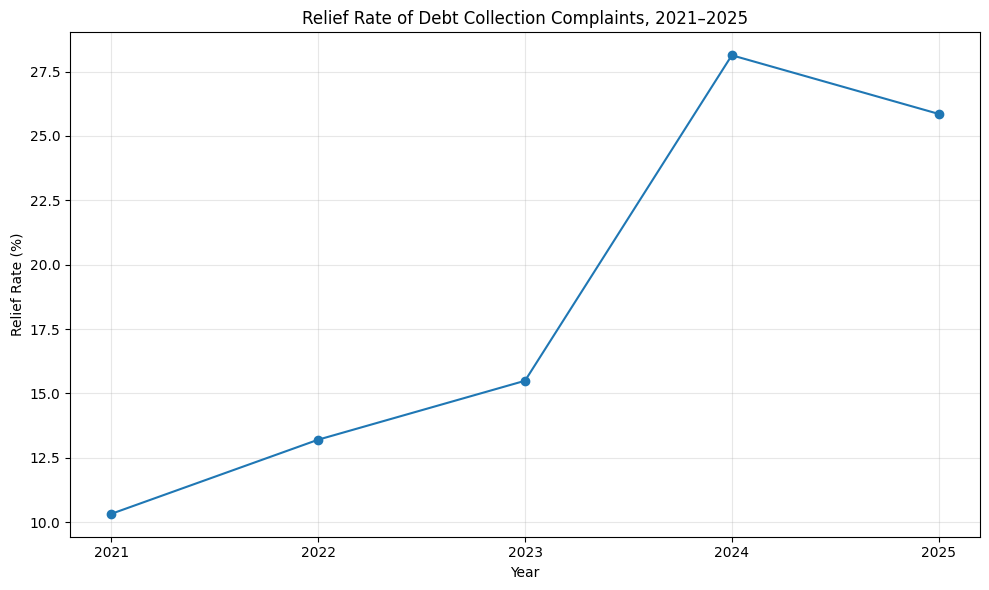

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    year_relief["Year"],
    year_relief["relief_rate"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Relief Rate (%)")
plt.title("Relief Rate of Debt Collection Complaints, 2021–2025")
plt.xticks([2021, 2022, 2023, 2024, 2025])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
company_relief = all_complaints.groupby("Company").agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

company_relief["relief_rate"] *= 100

In [45]:
company_relief_filtered = company_relief[
    company_relief["eligible_complaints"] >= 500
].copy()

company_relief_filtered = company_relief_filtered.sort_values(
    "relief_rate",
    ascending=False
)

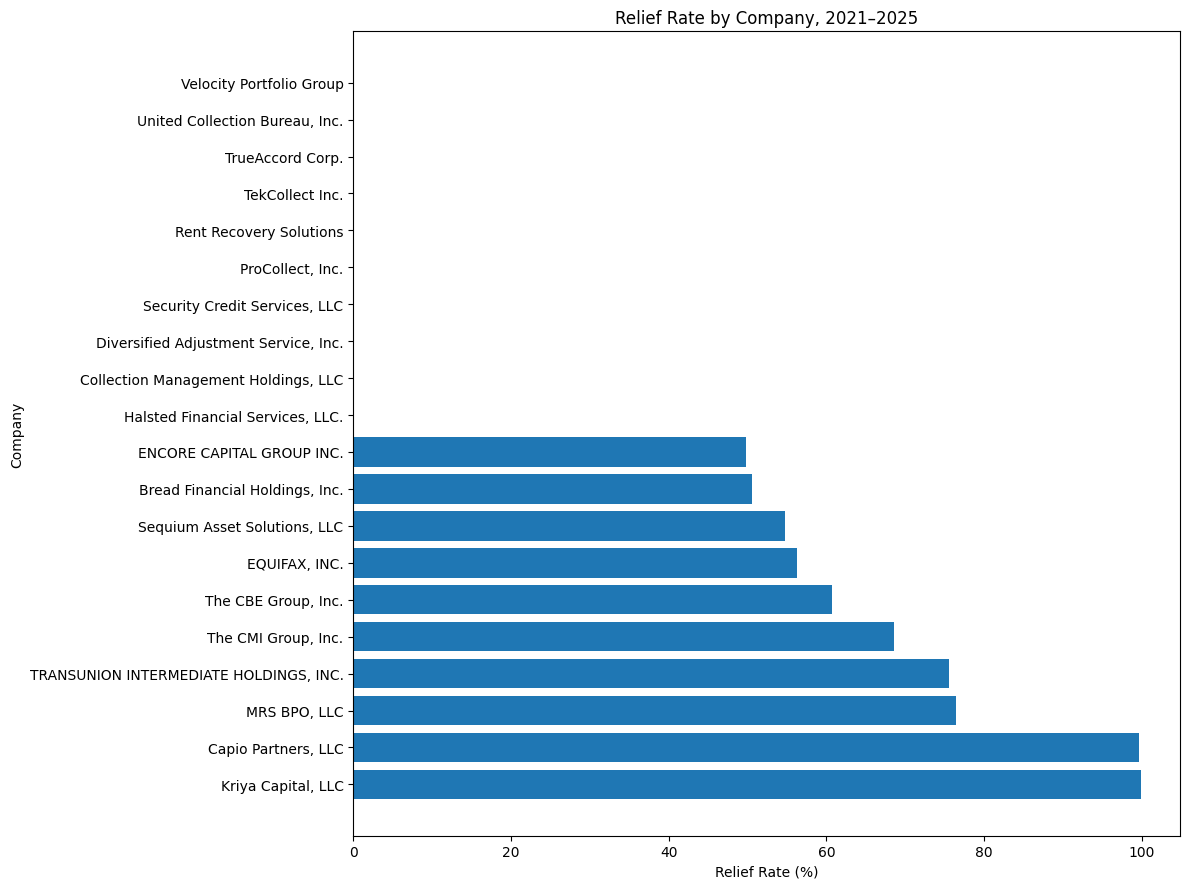

In [46]:
top_10 = company_relief_filtered.head(10)
bottom_10 = company_relief_filtered.tail(10)

company_plot = pd.concat([top_10, bottom_10])

plt.figure(figsize=(12, 9))

plt.barh(
    company_plot["Company"],
    company_plot["relief_rate"]
)

plt.xlabel("Relief Rate (%)")
plt.ylabel("Company")
plt.title("Relief Rate by Company, 2021–2025")
plt.tight_layout()
plt.show()

In [47]:
subproduct_relief = all_complaints.groupby("Sub-product").agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

subproduct_relief["relief_rate"] *= 100

In [48]:
subproduct_relief_filtered = subproduct_relief[
    subproduct_relief["eligible_complaints"] >= 500
].copy()

subproduct_relief_filtered = subproduct_relief_filtered.sort_values(
    "relief_rate",
    ascending=True
)

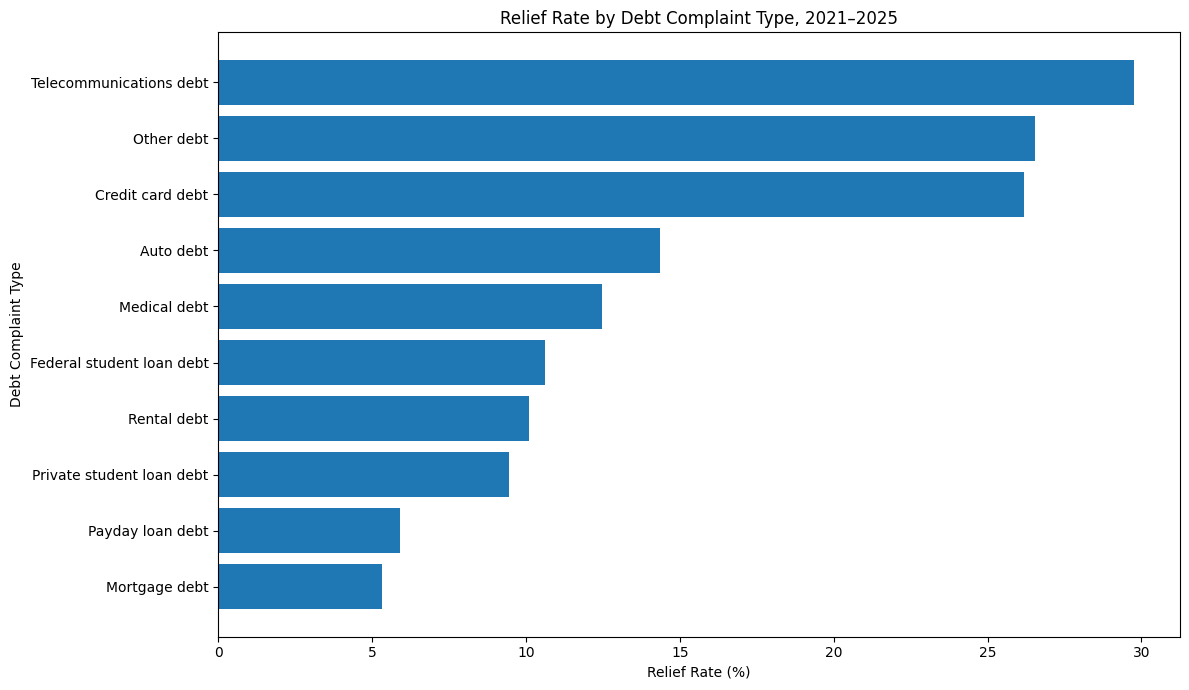

In [49]:
plt.figure(figsize=(12, 7))

plt.barh(
    subproduct_relief_filtered["Sub-product"],
    subproduct_relief_filtered["relief_rate"]
)

plt.xlabel("Relief Rate (%)")
plt.ylabel("Debt Complaint Type")
plt.title("Relief Rate by Debt Complaint Type, 2021–2025")
plt.tight_layout()
plt.show()

In [50]:
product_year = all_complaints[
    all_complaints["Year"].isin([2023, 2024])
].groupby(["Year", "Sub-product"]).agg(
    eligible_complaints=("Relief", "count"),
    relief_cases=("Relief", "sum"),
    relief_rate=("Relief", "mean")
).reset_index()

product_year["relief_rate"] *= 100

product_year.sort_values(
    ["Sub-product", "Year"]
)

,Year,Sub-product,eligible_complaints,relief_cases,relief_rate
0,2023,Auto debt,3272,330.0,10.085575
10,2024,Auto debt,4702,789.0,16.780094
1,2023,Credit card debt,15579,3469.0,22.267155
11,2024,Credit card debt,26890,7653.0,28.460394
2,2023,Federal student loan debt,423,38.0,8.983452
12,2024,Federal student loan debt,530,76.0,14.339623
3,2023,Medical debt,7321,945.0,12.908073
13,2024,Medical debt,7140,868.0,12.156863
4,2023,Mortgage debt,837,47.0,5.615293
14,2024,Mortgage debt,747,77.0,10.307898


In [51]:
comparison = product_year.pivot(
    index="Sub-product",
    columns="Year",
    values="relief_rate"
).reset_index()

comparison["change"] = comparison[2024] - comparison[2023]

comparison.sort_values("change", ascending=False)

Year,Sub-product,2023,2024,change
5,Other debt,13.274124,37.182711,23.908587
0,Auto debt,10.085575,16.780094,6.694519
1,Credit card debt,22.267155,28.460394,6.193240
2,Federal student loan debt,8.983452,14.339623,5.356171
4,Mortgage debt,5.615293,10.307898,4.692606
7,Private student loan debt,8.552632,9.821429,1.268797
6,Payday loan debt,5.551601,6.009746,0.458144
3,Medical debt,12.908073,12.156863,-0.751210
8,Rental debt,9.050279,NaN,NaN
9,Telecommunications debt,19.607843,NaN,NaN


In [52]:
composition = all_complaints[
    all_complaints["Year"].isin([2023, 2024])
].groupby(["Year", "Sub-product"]).size().reset_index(name="complaints")

composition["percent_of_year"] = (
    composition.groupby("Year")["complaints"]
    .transform(lambda x: x / x.sum() * 100)
)

composition.sort_values(
    ["Sub-product", "Year"]
)

,Year,Sub-product,complaints,percent_of_year
0,2023,Auto debt,3288,6.596581
10,2024,Auto debt,4721,6.921678
1,2023,Credit card debt,15602,31.301661
11,2024,Credit card debt,26933,39.487728
2,2023,Federal student loan debt,429,0.860685
12,2024,Federal student loan debt,534,0.782922
3,2023,Medical debt,7410,14.866383
13,2024,Medical debt,7265,10.651556
4,2023,Mortgage debt,838,1.681245
14,2024,Mortgage debt,750,1.099610
